In [59]:
import numpy as np
import pandas as pd

from utils.modeling import sample_scores
from utils.plotting import draw_violin_plot_single, draw_violin_plot, draw_pairwise_grouped_bar_plot

# Set seed for reproducibility
np.random.seed(27)

# Generate data

In [60]:
# Grader base means
graders = {
    "Human X": 5,
    "Human Y": 6,
    "Human Z": 6.5,
    "Autograder A": 2.0,
    "Autograder B": 2.0,
    "Autograder C": 4,
}

# LLM effects
llm_effects = {
    "LLM A": 2.0,
    "LLM B": 0.0
}

# Interaction effect: add a small boost
interaction_effects = {
    ("Autograder B", "LLM B"): 0.8,
    ("Autograder A", "LLM A"): 0.8
}

# Simulate dataset
rows = []
for grader, base_mean in graders.items():
    for llm, llm_adj in llm_effects.items():
        interaction = interaction_effects.get((grader, llm), 0.0)
        full_mean = base_mean + llm_adj + interaction
        scores = sample_scores(mean=full_mean)
        for score in scores:
            rows.append({
                "score": score,
                "grader": grader,
                "LLM": llm
            })


# Create dataframe
df = pd.DataFrame(rows)

# Question 1

## Question 1.1: Plot grader for LLM A

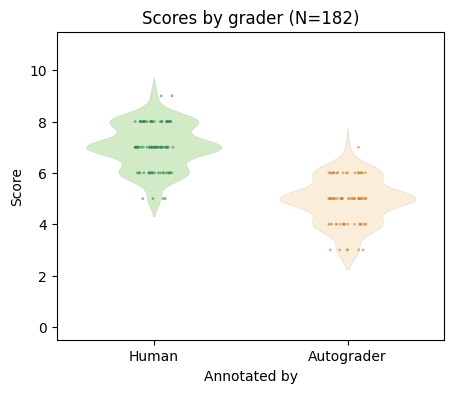

In [61]:
# Take only LLM A graded by Human X or Autograder A
df_tmp = df[(df['LLM']=='LLM A') & 
            ((df['grader']=='Autograder A') | 
             (df['grader']=='Human X'))].copy()
# rename columns for this example
df_tmp['grader'] = df_tmp['grader'].replace({
    'Autograder A': 'Autograder',
    'Human X': 'Human'
})

# Save data
df_tmp.to_csv("modeling_per_question/question1.1/data.csv", index=False)

# Plot
draw_violin_plot_single(ax = None, 
                           df = df_tmp, 
                           x_var = 'grader', 
                           color_scheme = '1autograder', 
                           x_label='Annotated by')

## Question 1.2: Plot grader for LLM A and LLM B

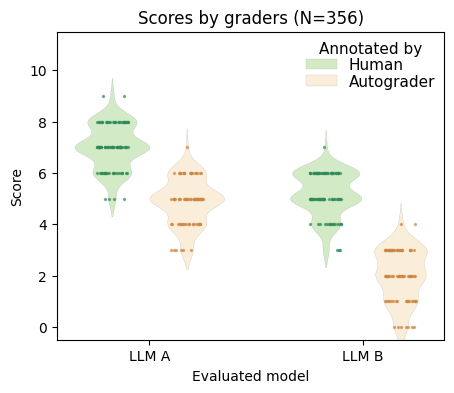

In [62]:
# Take all LLMs graded by Human X or Autograder A
df_tmp = df[((df['grader']=='Autograder A') | 
             (df['grader']=='Human X'))].copy()

# rename columns
df_tmp['grader'] = df_tmp['grader'].replace({
    'Autograder A': 'Autograder',
    'Human X': 'Human'
})

# Save data
df_tmp.to_csv("modeling_per_question/question1.2/data.csv", index=False)
df_tmp.to_csv("modeling_per_question/appendix_cutpoints/data.csv", index=False)

# Plot
draw_violin_plot(
    ax=None,
    df=df_tmp,
    x_var='LLM',
    color_scheme='1autograder',
    x_label='Evaluated model',
    dodge=True,
    y_lim=[-0.5, 11.5],
    legend_title='Annotated by',
    show_predictions=False,
    idata=None,
    pred_alpha=0.7,
    category_maps=None,
    show_items=False,
    jitter_strength=0.15,
)               

# Question 2

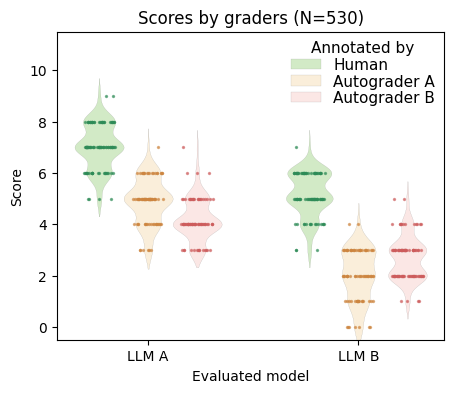

In [63]:
# Take all LLMs graded by Human X, Autograder A or Autograder B
df_tmp = df[((df['grader']=='Autograder A') | 
             (df['grader']=='Autograder B') |
             (df['grader']=='Human X'))].copy()

# rename columns
df_tmp['grader'] = df_tmp['grader'].replace({
    'Human X': 'Human'
})

# Save data
df_tmp.to_csv("modeling_per_question/question2/data.csv", index=False)

# Plot
draw_violin_plot(
    ax=None,
    df=df_tmp,
    x_var='LLM',
    color_scheme='2autograders',
    x_label='Evaluated model',
    dodge=True,
    y_lim=[-0.5, 11.5],
    legend_title='Annotated by',
    show_predictions=False,
    idata=None,
    pred_alpha=0.7,
    category_maps=None,
    show_items=False,
    jitter_strength=0.15,
)

# Question 3

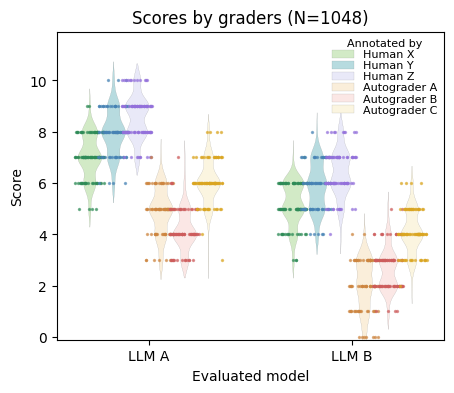

In [64]:
# Save data
df_tmp = df.copy()
df_tmp.to_csv("modeling_per_question/question3/data.csv", index=False)

# Plot
draw_violin_plot(
    ax=None,
    df=df_tmp,
    x_var='LLM',
    color_scheme='multiple_graders',
    x_label='Evaluated model',
    dodge=True,
    y_lim=[-0.1, 11.9],
    legend_title='Annotated by',
    show_predictions=False,
    idata=None,
    pred_alpha=0.7,
    category_maps=None,
    show_items=False,
    jitter_strength=0.15,
    legend_fontsize = 8
)

# Question 4

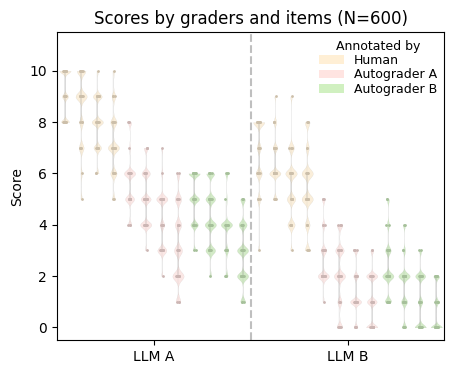

In [65]:
def sample_scores(mean, n_samples=30, std=1.2):
    """Sample scores with clipping to 0-10 range"""
    scores = np.random.normal(mean, std, n_samples)
    return np.clip(scores, 0, 10).round().astype(int)

# Grader base means
graders = {
    "Human": 7.0,        # Human rates much higher
    "Autograder A": 3.0, # Autograders rate much lower  
    "Autograder B": 2.5,
}

# LLM effects
llm_effects = {
    "LLM A": 1.5,  # LLM A produces better outputs
    "LLM B": -1.0  # LLM B produces worse outputs
}

# Item difficulties 
item_difficulties = {
    1: 1.0,   # Easy item
    2: 0.3,   # Slightly easy
    3: -0.3,  # Slightly hard
    4: -1.0   # Hard item
}

# Simulate dataset
rows = []
for grader, base_mean in graders.items():
    for llm, llm_adj in llm_effects.items():
        for item, item_difficulty in item_difficulties.items():
            
            # Simple additive model - no interactions or different sensitivities
            full_mean = base_mean + llm_adj + item_difficulty
            
            # Sample scores
            scores = sample_scores(mean=full_mean, n_samples=25)
            
            for score in scores:
                rows.append({
                    "score": score,
                    "grader": grader,
                    "LLM": llm,
                    "item": item
                })

# Create dataframe
df = pd.DataFrame(rows)

df.to_csv("modeling_per_question/question4/data.csv", index=False)


# Plot
draw_violin_plot(
    ax=None, 
    df=df, 
    x_var='LLM',
    color_scheme='2autograders',
    x_label=None,
    dodge=True,
    y_lim=[-0.5, 11.5],
    legend_title='Annotated by',
    show_predictions=False,
    idata=None,
    pred_alpha=0.2,
    show_items=True,
    jitter_strength=0.15,
    legend_fontsize=9
)


# Question 5

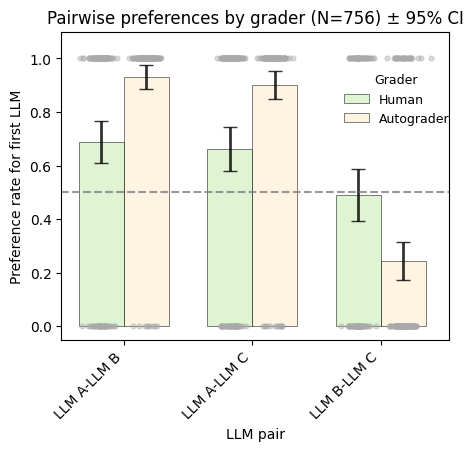

In [66]:
rows = []

model_lengths = {
    'LLM A': 400, 
    'LLM B': 300,   
    'LLM C': 350   
}

pairs = [("LLM A", "LLM B"), ("LLM A", "LLM C"), ("LLM B", "LLM C")]
graders = ["Human", "Autograder"]

# Base LLM pair preferences 
pair_effects = {
    ("LLM A", "LLM B"): 0.4,
    ("LLM A", "LLM C"): 1.1, 
    ("LLM B", "LLM C"): -0.1
}

# Grader-specific length bias
length_bias = {
    "Human": 0,      
    "Autograder": 0.02  
}

for pair in pairs:
    llm1, llm2 = pair
    base_logit = pair_effects[pair]
    expected_diff = model_lengths[llm1] - model_lengths[llm2]
    
    for grader in graders:
        n_comparisons = np.random.randint(100, 150)
        
        for i in range(n_comparisons):
            length_diff = np.random.normal(expected_diff, 40)
            
            # Base preference + grader-specific length bias
            logit_p = base_logit + length_bias[grader] * length_diff
            prob_choose_first = 1 / (1 + np.exp(-logit_p))
            first_is_chosen = np.random.binomial(1, prob_choose_first)
            
            rows.append({
                "LLM_1": llm1,
                "LLM_2": llm2,
                "grader": grader,
                "first_is_chosen": first_is_chosen,
                "length_diff": length_diff,
                "llm_pair": f"{llm1}-{llm2}"
            })

df = pd.DataFrame(rows)

df.to_csv("modeling_per_question/question5/data.csv", index=False)


draw_pairwise_grouped_bar_plot(
    ax=None, 
    df=df, 
    color_scheme='1autograder',  
    x_label='LLM pair',
    y_lim=[-0.05, 1.1],
    legend_title='Grader',
    show_individual_points=True,
    show_ci=True
)